# 03 Feature Engineering

## AI-Based Environmental Pollution Forecasting System

### Objective

The objective of this notebook is to transform the cleaned dataset into a high-quality feature set for machine learning and deep learning models. Feature engineering plays a crucial role in improving prediction accuracy by extracting meaningful information from historical pollution and weather observations.

This notebook prepares datasets for:

- CatBoost
- LightGBM
- XGBoost
- Long Short-Term Memory (LSTM)
- Temporal Fusion Transformer (TFT)

### Major Tasks

- Load cleaned dataset
- Create temporal features
- Generate lag features
- Compute rolling statistics
- Create cyclic features
- Build pollutant interaction features
- Encode categorical variables
- Select important features
- Scale numerical variables
- Prepare sequence datasets for LSTM
- Prepare time-series dataset for TFT
- Save processed datasets and preprocessing artifacts



In [1]:
# =============================================================================
# Import Required Libraries
# =============================================================================

# Standard Libraries
import os
import warnings
import pickle
from pathlib import Path

warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# Scikit-Learn
from sklearn.preprocessing import (LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler)
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_regression)

from sklearn.model_selection import train_test_split

# Gradient Boosting Models (Feature Importance)
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 70)
print("Feature Engineering Notebook Initialized Successfully")
print("=" * 70)

Feature Engineering Notebook Initialized Successfully


In [2]:
# =============================================================================
# Project Directory Structure
# =============================================================================

from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "Data"
RAW_DIR = DATA_DIR / "Raw"
PROCESSED_DIR = DATA_DIR / "Processed"
MODEL_DIR = ROOT_DIR / "models"

# Create required folders
for folder in [PROCESSED_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project Root    : {ROOT_DIR}")
print(f"Processed Data  : {PROCESSED_DIR}")
print(f"Model Folder    : {MODEL_DIR}")

Project Root    : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026
Processed Data  : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026/Data/Processed
Model Folder    : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026/models


In [3]:
# =============================================================================
# Load Cleaned Dataset
# =============================================================================

DATA_PATH = PROCESSED_DIR / "cleaned_data.csv"
df = pd.read_csv(DATA_PATH)
print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
display(df.head())

Dataset Loaded Successfully
Rows    : 3,429,120
Columns : 26


,timestamp,pm25,pm10,nitric_oxide,nitrogen_dioxide,nitrogen_oxides,ammonia,sulfur_dioxide,carbon_monoxide,ozone,ambient_temperature,relative_humidity,solar_radiation,rainfall,state,city,latitude,longitude,calculated_aqi,month,hour,dayofweek,is_weekend,state_encoded,city_encoded,source_file
0,2017-01-01 00:00:00,129.125,227.00,26.642500,59.610000,66.025004,51.324998,21.520000,1.9500,8.330000,14.50,71.83,12.25,0.0,Delhi,"Anand Vihar ( , )",28.6508,77.3152,90.105553,1,0,6,1,6,4,AQI_Dataset.csv
1,2017-01-01 00:00:00,129.125,119.49,26.642500,55.509998,29.889999,15.991283,18.889999,1.9975,0.710000,21.81,19.88,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,0,6,1,7,38,AQI_Dataset.csv
2,2017-01-01 01:00:00,129.125,119.49,20.770000,53.560001,29.889999,15.991283,25.139999,1.7000,1.286667,20.99,29.47,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,1,6,1,7,38,AQI_Dataset.csv
3,2017-01-01 01:00:00,129.125,226.17,26.642500,59.610000,66.025004,51.324998,21.760000,1.9975,8.980000,13.66,73.25,12.17,0.0,Delhi,"Anand Vihar ( , )",28.6508,77.3152,90.105553,1,1,6,1,6,4,AQI_Dataset.csv
4,2017-01-01 02:00:00,125.980,119.49,24.290001,51.040001,29.889999,15.991283,30.700001,1.5300,1.863333,20.08,42.36,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,2,6,1,7,38,AQI_Dataset.csv


In [4]:
# =============================================================================
# Dataset Information
# =============================================================================

print("=" * 70)
print("Dataset Overview")
print("=" * 70)
display(df.info())
display(df.describe(include="all").T)
print("\nMissing Values\n")
display(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate Rows :", df.duplicated().sum())

Dataset Overview
<class 'pandas.DataFrame'>
RangeIndex: 3429120 entries, 0 to 3429119
Data columns (total 26 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            str    
 1   pm25                 float64
 2   pm10                 float64
 3   nitric_oxide         float64
 4   nitrogen_dioxide     float64
 5   nitrogen_oxides      float64
 6   ammonia              float64
 7   sulfur_dioxide       float64
 8   carbon_monoxide      float64
 9   ozone                float64
 10  ambient_temperature  float64
 11  relative_humidity    float64
 12  solar_radiation      float64
 13  rainfall             float64
 14  state                str    
 15  city                 str    
 16  latitude             float64
 17  longitude            float64
 18  calculated_aqi       float64
 19  month                int64  
 20  hour                 int64  
 21  dayofweek            int64  
 22  is_weekend           int64  
 23  state_encoded        int64

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,3429120,83231,2023-02-21 10:00:00,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25,3429120.0,NaN,NaN,NaN,47.537327,35.503827,0.0,21.0,36.165,64.25,129.125
pm10,3429120.0,NaN,NaN,NaN,105.605553,75.149611,0.0,48.6875,82.75,142.07,282.14377
nitric_oxide,3429120.0,NaN,NaN,NaN,8.938724,8.07736,0.0,2.78,6.0,12.325,26.6425
nitrogen_dioxide,3429120.0,NaN,NaN,NaN,21.555827,16.765401,0.0,8.86,16.370001,29.16,59.61
...,...,...,...,...,...,...,...,...,...,...,...
dayofweek,3429120.0,NaN,NaN,NaN,2.9924,1.993942,0.0,1.0,3.0,5.0,6.0
is_weekend,3429120.0,NaN,NaN,NaN,0.283112,0.45051,0.0,0.0,0.0,1.0,1.0
state_encoded,3429120.0,NaN,NaN,NaN,9.790714,5.345441,0.0,6.0,11.0,14.0,18.0
city_encoded,3429120.0,NaN,NaN,NaN,31.088375,19.212797,0.0,14.0,30.0,48.0,65.0



Missing Values



Series([], dtype: int64)


Duplicate Rows : 0


# 1. Temporal Feature Engineering

Temporal information plays an important role in air pollution forecasting.

In this section, we create several time-based features from the datetime column that help machine learning models understand seasonal and periodic patterns.

Features generated:

- Year
- Month
- Quarter
- Week of Year
- Day
- Day of Week
- Day of Year
- Hour
- Is Weekend
- Season

In [5]:
# =============================================================================
# Temporal Feature Engineering
# =============================================================================

# Copy dataframe
feature_df = df.copy()

# Convert to datetime using the correct lowercase column name
feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

# Basic Date Features
feature_df["Year"] = feature_df["timestamp"].dt.year
feature_df["Month"] = feature_df["timestamp"].dt.month
feature_df["Quarter"] = feature_df["timestamp"].dt.quarter
feature_df["Week"] = feature_df["timestamp"].dt.isocalendar().week.astype(int)
feature_df["Day"] = feature_df["timestamp"].dt.day
feature_df["DayOfWeek"] = feature_df["timestamp"].dt.dayofweek
feature_df["DayOfYear"] = feature_df["timestamp"].dt.dayofyear
feature_df["Hour"] = feature_df["timestamp"].dt.hour

# Weekend Feature
feature_df["IsWeekend"] = (feature_df["DayOfWeek"] >= 5).astype(int)

print("="*70)
print("Temporal Features Created Successfully")
print("="*70)

# Display Preview
display(feature_df[["timestamp", "Year", "Month", "Quarter", "Week", "Day", "DayOfWeek", "Hour", "IsWeekend"]].head())

Temporal Features Created Successfully


,timestamp,Year,Month,Quarter,Week,Day,DayOfWeek,Hour,IsWeekend
0,2017-01-01 00:00:00,2017,1,1,52,1,6,0,1
1,2017-01-01 00:00:00,2017,1,1,52,1,6,0,1
2,2017-01-01 01:00:00,2017,1,1,52,1,6,1,1
3,2017-01-01 01:00:00,2017,1,1,52,1,6,1,1
4,2017-01-01 02:00:00,2017,1,1,52,1,6,2,1


In [6]:
# =============================================================================
# Season Feature
# =============================================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    else:
        return "PostMonsoon"


feature_df["Season"] = feature_df["Month"].apply(get_season)
print("="*70)
print("Season Feature Created")
print("="*70)
display(feature_df["Season"].value_counts())

Season Feature Created


Season
Monsoon        1098562
Summer          892367
Winter          866731
PostMonsoon     571460
Name: count, dtype: int64

# 2. Cyclic Feature Engineering

Machine learning models interpret Month, Hour, and Day as numerical values.

For example,

Month 12 and Month 1 are actually adjacent in time,
but numerically they appear far apart.

To preserve cyclic behaviour, sine and cosine transformations are applied.

In [7]:
# =============================================================================
# Cyclic Feature Engineering
# =============================================================================

# Month
feature_df["Month_sin"] = np.sin(2 * np.pi * feature_df["Month"] / 12)
feature_df["Month_cos"] = np.cos(2 * np.pi * feature_df["Month"] / 12)
# Day of Week
feature_df["DayOfWeek_sin"] = np.sin(2 * np.pi * feature_df["DayOfWeek"] / 7)

feature_df["DayOfWeek_cos"] = np.cos(2 * np.pi * feature_df["DayOfWeek"] / 7)

# Hour
feature_df["Hour_sin"] = np.sin(2 * np.pi * feature_df["Hour"] / 24)

feature_df["Hour_cos"] = np.cos(2 * np.pi * feature_df["Hour"] / 24)

print("="*70)
print("Cyclic Features Created Successfully")
print("="*70)

display(feature_df[["Month", "Month_sin", "Month_cos", "Hour", "Hour_sin", "Hour_cos"]].head())

Cyclic Features Created Successfully


,Month,Month_sin,Month_cos,Hour,Hour_sin,Hour_cos
0,1,0.5,0.866025,0,0.000000,1.000000
1,1,0.5,0.866025,0,0.000000,1.000000
2,1,0.5,0.866025,1,0.258819,0.965926
3,1,0.5,0.866025,1,0.258819,0.965926
4,1,0.5,0.866025,2,0.500000,0.866025


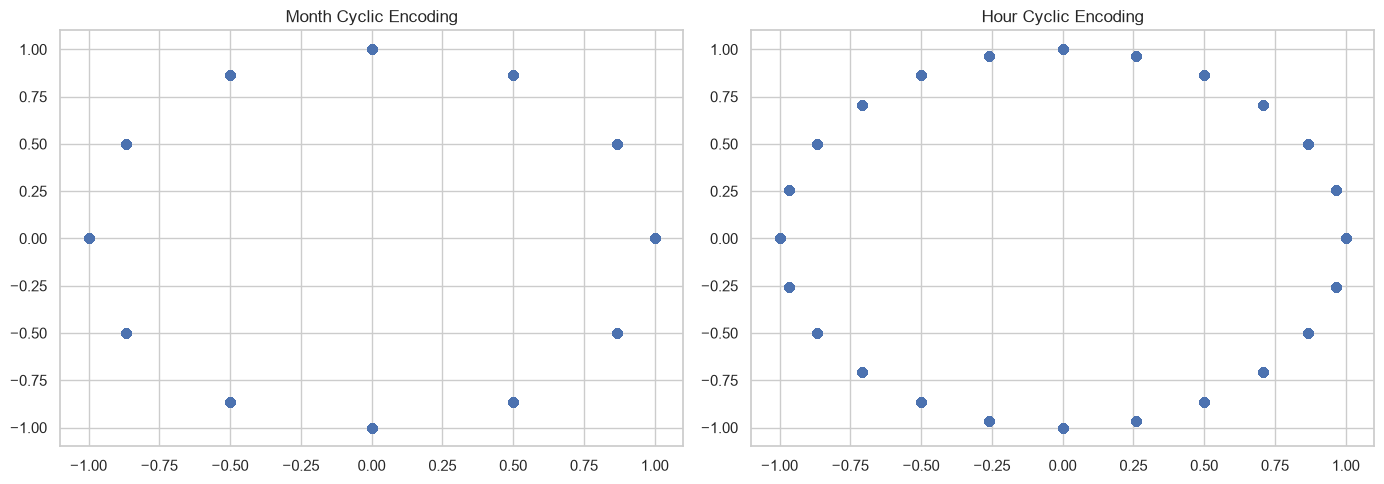

In [8]:
# =============================================================================
# Visual Verification of Cyclic Features
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Month Encoding
axes[0].scatter(feature_df["Month_sin"], feature_df["Month_cos"], alpha=0.4)
axes[0].set_title("Month Cyclic Encoding")
# Hour Encoding
axes[1].scatter(feature_df["Hour_sin"], feature_df["Hour_cos"], alpha=0.4)
axes[1].set_title("Hour Cyclic Encoding")
plt.tight_layout()
plt.show()

# 3. Pollution & Weather Feature Engineering

Feature interactions help machine learning models capture nonlinear
relationships between pollutants and meteorological conditions.

In this section we create:

- Pollutant Ratio Features
- Weather Interaction Features
- Temperature Difference
- Humidity Difference
- Wind Interaction Features
- Pollution Index Features

These engineered features are especially useful for:

- CatBoost
- LightGBM
- XGBoost
- LSTM
- TFT

In [9]:
# =============================================================================
# Pollutant Ratio Features
# =============================================================================

print("=" * 70)
print("Creating Pollutant Ratio Features...")
print("=" * 70)

EPSILON = 1e-6

# Updated to match your exact standardized column names
ratio_features = {
    ("pm25", "pm10"): "PM25_PM10_Ratio",
    ("nitrogen_dioxide", "sulfur_dioxide"): "NO2_SO2_Ratio",
    ("carbon_monoxide", "nitrogen_dioxide"): "CO_NO2_Ratio",
    ("ozone", "nitrogen_dioxide"): "O3_NO2_Ratio"
}

created_features = []

for (num, den), new_col in ratio_features.items():

    # Check if both columns exist in the dataframe
    if num in feature_df.columns and den in feature_df.columns:

        # Calculate ratio, adding EPSILON to denominator to prevent division by zero
        feature_df[new_col] = (feature_df[num] / (feature_df[den] + EPSILON))

        created_features.append(new_col)
    else:
        print(f"Skipped {new_col}: Missing {num} or {den}")

print(f"Created {len(created_features)} ratio features")

if created_features:
    display(feature_df[created_features].head())

Creating Pollutant Ratio Features...
Created 4 ratio features


,PM25_PM10_Ratio,NO2_SO2_Ratio,CO_NO2_Ratio,O3_NO2_Ratio
0,0.568833,2.769981,0.032713,0.139742
1,1.080634,2.938592,0.035985,0.012790
2,1.080634,2.130469,0.031740,0.024023
3,0.570920,2.739430,0.033509,0.150646
4,1.054314,1.662541,0.029976,0.036507


In [10]:
# =============================================================================
# Weather Interaction Features
# =============================================================================

print("=" * 70)
print("Creating Weather Interaction Features...")
print("=" * 70)

# Temperature × Humidity
if {"ambient_temperature", "relative_humidity"}.issubset(feature_df.columns):
    feature_df["Temp_Humidity"] = (feature_df["ambient_temperature"] * feature_df["relative_humidity"])
    print("Created Temp_Humidity")

# Temperature × Solar Radiation (Using available data)
if {"ambient_temperature", "solar_radiation"}.issubset(feature_df.columns):
    feature_df["Temp_Solar"] = (feature_df["ambient_temperature"] * feature_df["solar_radiation"])
    print("Created Temp_Solar")

# Humidity × Solar Radiation (Using available data)
if {"relative_humidity", "solar_radiation"}.issubset(feature_df.columns):
    feature_df["Humidity_Solar"] = (feature_df["relative_humidity"] * feature_df["solar_radiation"])
    print("Created Humidity_Solar")


print("Weather interaction features created successfully.")
display(feature_df[["ambient_temperature", "relative_humidity", "solar_radiation", "Temp_Humidity", "Temp_Solar"]].head())

Creating Weather Interaction Features...
Created Temp_Humidity
Created Temp_Solar
Created Humidity_Solar
Weather interaction features created successfully.


,ambient_temperature,relative_humidity,solar_radiation,Temp_Humidity,Temp_Solar
0,14.50,71.83,12.25,1041.5350,177.6250
1,21.81,19.88,0.70,433.5828,15.2670
2,20.99,29.47,0.70,618.5753,14.6930
3,13.66,73.25,12.17,1000.5950,166.2422
4,20.08,42.36,0.70,850.5888,14.0560


In [11]:
# =============================================================================
# Pollutant Interaction Features
# =============================================================================

print("=" * 70)
print("Creating Pollution Interaction Features...")
print("=" * 70)

# Updated to match the exact standardized column names in your dataset
# Wind Speed and Pressure were replaced since they are not in your CSV
interaction_pairs = [
    ("pm25", "ambient_temperature"),
    ("pm25", "relative_humidity"),
    ("pm10", "relative_humidity"),
    ("nitrogen_dioxide", "solar_radiation"),   # Solar radiation drives NO2 breakdown
    ("sulfur_dioxide", "ambient_temperature")  # Temp impacts SO2 dispersion
]

generated = []

for col1, col2 in interaction_pairs:
    # Check if both columns exist in the dataframe
    if col1 in feature_df.columns and col2 in feature_df.columns:
        # Create a clean feature name
        feature_name = f"{col1}_{col2}"
        
        # Calculate the interaction (multiplication)
        feature_df[feature_name] = (feature_df[col1] * feature_df[col2])
        generated.append(feature_name)
    else:
        print(f"Skipped interaction: Missing '{col1}' or '{col2}'")

print(f"Created {len(generated)} interaction features")

if generated:
    display(feature_df[generated].head())

Creating Pollution Interaction Features...
Created 5 interaction features


,pm25_ambient_temperature,pm25_relative_humidity,pm10_relative_humidity,nitrogen_dioxide_solar_radiation,sulfur_dioxide_ambient_temperature
0,1872.31250,9275.04875,16305.4100,730.222502,312.040007
1,2816.21625,2567.00500,2375.4612,38.856999,411.990887
2,2710.33375,3805.31375,3521.3703,37.492001,527.688587
3,1763.84750,9458.40625,16566.9525,725.453702,297.241603
4,2529.67840,5336.51280,5061.5964,35.728001,616.456015


In [12]:
# =============================================================================
# Feature Summary
# =============================================================================

print("=" * 70)
print("Feature Engineering Summary")
print("=" * 70)
print(f"Dataset Shape : {feature_df.shape}")
new_features = sorted(list(set(feature_df.columns) - set(df.columns)))
print(f"\nNew Features Created : {len(new_features)}\n")

for feature in new_features:
    print(feature)

display(feature_df.head())

Feature Engineering Summary
Dataset Shape : (3429120, 54)

New Features Created : 28

CO_NO2_Ratio
Day
DayOfWeek
DayOfWeek_cos
DayOfWeek_sin
DayOfYear
Hour
Hour_cos
Hour_sin
Humidity_Solar
IsWeekend
Month
Month_cos
Month_sin
NO2_SO2_Ratio
O3_NO2_Ratio
PM25_PM10_Ratio
Quarter
Season
Temp_Humidity
Temp_Solar
Week
Year
nitrogen_dioxide_solar_radiation
pm10_relative_humidity
pm25_ambient_temperature
pm25_relative_humidity
sulfur_dioxide_ambient_temperature


,timestamp,pm25,pm10,nitric_oxide,nitrogen_dioxide,nitrogen_oxides,ammonia,sulfur_dioxide,carbon_monoxide,ozone,ambient_temperature,relative_humidity,solar_radiation,rainfall,state,city,latitude,longitude,calculated_aqi,month,hour,dayofweek,is_weekend,state_encoded,city_encoded,source_file,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Season,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Hour_sin,Hour_cos,PM25_PM10_Ratio,NO2_SO2_Ratio,CO_NO2_Ratio,O3_NO2_Ratio,Temp_Humidity,Temp_Solar,Humidity_Solar,pm25_ambient_temperature,pm25_relative_humidity,pm10_relative_humidity,nitrogen_dioxide_solar_radiation,sulfur_dioxide_ambient_temperature
0,2017-01-01 00:00:00,129.125,227.00,26.642500,59.610000,66.025004,51.324998,21.520000,1.9500,8.330000,14.50,71.83,12.25,0.0,Delhi,"Anand Vihar ( , )",28.6508,77.3152,90.105553,1,0,6,1,6,4,AQI_Dataset.csv,2017,1,1,52,1,6,1,0,1,Winter,0.5,0.866025,-0.781831,0.62349,0.000000,1.000000,0.568833,2.769981,0.032713,0.139742,1041.5350,177.6250,879.9175,1872.31250,9275.04875,16305.4100,730.222502,312.040007
1,2017-01-01 00:00:00,129.125,119.49,26.642500,55.509998,29.889999,15.991283,18.889999,1.9975,0.710000,21.81,19.88,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,0,6,1,7,38,AQI_Dataset.csv,2017,1,1,52,1,6,1,0,1,Winter,0.5,0.866025,-0.781831,0.62349,0.000000,1.000000,1.080634,2.938592,0.035985,0.012790,433.5828,15.2670,13.9160,2816.21625,2567.00500,2375.4612,38.856999,411.990887
2,2017-01-01 01:00:00,129.125,119.49,20.770000,53.560001,29.889999,15.991283,25.139999,1.7000,1.286667,20.99,29.47,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,1,6,1,7,38,AQI_Dataset.csv,2017,1,1,52,1,6,1,1,1,Winter,0.5,0.866025,-0.781831,0.62349,0.258819,0.965926,1.080634,2.130469,0.031740,0.024023,618.5753,14.6930,20.6290,2710.33375,3805.31375,3521.3703,37.492001,527.688587
3,2017-01-01 01:00:00,129.125,226.17,26.642500,59.610000,66.025004,51.324998,21.760000,1.9975,8.980000,13.66,73.25,12.17,0.0,Delhi,"Anand Vihar ( , )",28.6508,77.3152,90.105553,1,1,6,1,6,4,AQI_Dataset.csv,2017,1,1,52,1,6,1,1,1,Winter,0.5,0.866025,-0.781831,0.62349,0.258819,0.965926,0.570920,2.739430,0.033509,0.150646,1000.5950,166.2422,891.4525,1763.84750,9458.40625,16566.9525,725.453702,297.241603
4,2017-01-01 02:00:00,125.980,119.49,24.290001,51.040001,29.889999,15.991283,30.700001,1.5300,1.863333,20.08,42.36,0.70,0.0,Gujarat,"Maninagar, Ahmedabad ( , )",22.9962,72.5996,90.105553,1,2,6,1,7,38,AQI_Dataset.csv,2017,1,1,52,1,6,1,2,1,Winter,0.5,0.866025,-0.781831,0.62349,0.500000,0.866025,1.054314,1.662541,0.029976,0.036507,850.5888,14.0560,29.6520,2529.67840,5336.51280,5061.5964,35.728001,616.456015


# 4. Lag Feature Engineering

Historical pollution values are one of the strongest predictors of future air quality.

Lag features allow the model to learn temporal dependencies by using previous observations.

The following lag features will be generated (per city):

- Lag 1
- Lag 2
- Lag 3
- Lag 6
- Lag 12
- Lag 24
- Lag 48
- Lag 72

These features significantly improve the performance of:

- CatBoost
- LightGBM
- XGBoost
- LSTM
- TFT

In [13]:
# =============================================================================
# Lag Feature Engineering
# =============================================================================

print("=" * 70)
print("Creating Lag Features...")
print("=" * 70)

TIME_COL = "timestamp"
GROUP_COL = "city"
TARGET = "calculated_aqi"

# Convert timestamp
feature_df[TIME_COL] = pd.to_datetime(feature_df[TIME_COL])

# Sort dataset
feature_df = feature_df.sort_values(by=[GROUP_COL, TIME_COL]).reset_index(drop=True)
lag_periods = [1, 2, 3, 6, 12, 24, 48, 72]

for lag in lag_periods:
    feature_df[f"{TARGET}_lag_{lag}"] = (feature_df.groupby(GROUP_COL)[TARGET].shift(lag))

print(f"Created {len(lag_periods)} lag features.")

display(
    feature_df[
        [TIME_COL, GROUP_COL, TARGET] +
        [f"{TARGET}_lag_{i}" for i in lag_periods]
    ].head(15)
)

Creating Lag Features...
Created 8 lag features.


,timestamp,city,calculated_aqi,calculated_aqi_lag_1,calculated_aqi_lag_2,calculated_aqi_lag_3,calculated_aqi_lag_6,calculated_aqi_lag_12,calculated_aqi_lag_24,calculated_aqi_lag_48,calculated_aqi_lag_72
0,2022-10-21 12:00:00,"32Bungalows, Bhilai (, )",90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-10-21 13:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-10-21 14:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-10-21 15:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN
4,2022-10-21 16:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10,2022-10-21 22:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN
11,2022-10-21 23:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN
12,2022-10-22 00:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN
13,2022-10-22 01:00:00,"32Bungalows, Bhilai (, )",90.105553,90.105553,90.105553,90.105553,90.105553,90.105553,NaN,NaN,NaN


In [14]:
# =============================================================================
# Rolling Window Features
# =============================================================================

print("=" * 70)
print("Creating Rolling Statistics...")
print("=" * 70)
windows = [3, 6, 12, 24]
for window in windows:
    grouped = feature_df.groupby(GROUP_COL)[TARGET]
    feature_df[f"{TARGET}_rolling_mean_{window}"] = (grouped.transform(lambda x:x.shift(1).rolling(window).mean()))
    feature_df[f"{TARGET}_rolling_std_{window}"] = (grouped.transform(lambda x: x.shift(1).rolling(window).std()))
    feature_df[f"{TARGET}_rolling_min_{window}"] = (grouped.transform(lambda x: x.shift(1).rolling(window).min()))
    feature_df[f"{TARGET}_rolling_max_{window}"] = (grouped.transform(lambda x: x.shift(1).rolling(window).max()))

print("Rolling statistics completed.")

Creating Rolling Statistics...
Rolling statistics completed.


In [15]:
# =============================================================================
# Expanding & Exponential Moving Statistics
# =============================================================================

print("=" * 70)
print("Creating Expanding Features...")
print("=" * 70)
grouped = feature_df.groupby(GROUP_COL)[TARGET]
feature_df[f"{TARGET}_expanding_mean"] = (grouped.transform(lambda x:x.shift(1).expanding().mean()))
feature_df[f"{TARGET}_ema_12"] = (grouped.transform(lambda x:x.shift(1).ewm(span=12, adjust=False).mean()))
feature_df[f"{TARGET}_ema_24"] = (grouped.transform(lambda x:x.shift(1).ewm(span=24, adjust=False).mean()))

print("Expanding statistics completed.")

Creating Expanding Features...
Expanding statistics completed.


In [16]:
# =============================================================================
# Verify Time-Series Features
# =============================================================================

ts_features = [

    col

    for col in feature_df.columns

    if "lag" in col.lower()
    or "rolling" in col.lower()
    or "ema" in col.lower()
    or "expanding" in col.lower()]
print("=" * 70)
print("Time-Series Feature Summary")
print("=" * 70)
print(f"Total Time-Series Features : {len(ts_features)}")
display(feature_df[ts_features].head())
print("\nMissing Values")
display(feature_df[ts_features].isnull().sum())

Time-Series Feature Summary
Total Time-Series Features : 27


,calculated_aqi_lag_1,calculated_aqi_lag_2,calculated_aqi_lag_3,calculated_aqi_lag_6,calculated_aqi_lag_12,calculated_aqi_lag_24,calculated_aqi_lag_48,calculated_aqi_lag_72,calculated_aqi_rolling_mean_3,calculated_aqi_rolling_std_3,calculated_aqi_rolling_min_3,calculated_aqi_rolling_max_3,calculated_aqi_rolling_mean_6,calculated_aqi_rolling_std_6,calculated_aqi_rolling_min_6,calculated_aqi_rolling_max_6,calculated_aqi_rolling_mean_12,calculated_aqi_rolling_std_12,calculated_aqi_rolling_min_12,calculated_aqi_rolling_max_12,calculated_aqi_rolling_mean_24,calculated_aqi_rolling_std_24,calculated_aqi_rolling_min_24,calculated_aqi_rolling_max_24,calculated_aqi_expanding_mean,calculated_aqi_ema_12,calculated_aqi_ema_24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.105553,90.105553,90.105553
2,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.105553,90.105553,90.105553
3,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,90.105553,0.0,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.105553,90.105553,90.105553
4,90.105553,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,90.105553,0.0,90.105553,90.105553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.105553,90.105553,90.105553



Missing Values


calculated_aqi_lag_1               66
calculated_aqi_lag_2              132
calculated_aqi_lag_3              198
calculated_aqi_lag_6              396
calculated_aqi_lag_12             792
                                 ... 
calculated_aqi_rolling_min_24    1584
calculated_aqi_rolling_max_24    1584
calculated_aqi_expanding_mean      66
calculated_aqi_ema_12              66
calculated_aqi_ema_24              66
Length: 27, dtype: int64

# 5. Feature Selection

The engineered dataset now contains a large number of features.

Using every feature can lead to:

- Overfitting
- Increased training time
- Multicollinearity
- Reduced model generalization

In this section we perform:

- Correlation Analysis
- Low Variance Feature Removal
- Mutual Information Analysis

The final feature set will later be validated using tree-based feature importance.

In [17]:
# =============================================================================
# Remove Highly Correlated Features
# =============================================================================

print("=" * 70)
print("Removing Highly Correlated Features...")
print("=" * 70)

TARGET = "calculated_aqi"

# Numeric columns only
numeric_df = feature_df.select_dtypes(include=[np.number])

# Exclude target
feature_columns = numeric_df.drop(columns=[TARGET], errors="ignore")
corr_matrix = feature_columns.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlated_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)]
print(f"Highly Correlated Features : {len(correlated_features)}")
display(correlated_features[:20])
feature_df = feature_df.drop(columns=correlated_features, errors="ignore")

print(f"Remaining Features : {feature_df.shape[1]}")

Removing Highly Correlated Features...
Highly Correlated Features : 26


['Month',
 'Quarter',
 'Week',
 'DayOfWeek',
 'DayOfYear',
 'Hour',
 'IsWeekend',
 'Temp_Solar',
 'calculated_aqi_lag_2',
 'calculated_aqi_lag_3',
 'calculated_aqi_lag_6',
 'calculated_aqi_lag_12',
 'calculated_aqi_rolling_mean_3',
 'calculated_aqi_rolling_min_3',
 'calculated_aqi_rolling_max_3',
 'calculated_aqi_rolling_mean_6',
 'calculated_aqi_rolling_min_6',
 'calculated_aqi_rolling_max_6',
 'calculated_aqi_rolling_mean_12',
 'calculated_aqi_rolling_min_12']

Remaining Features : 55


In [18]:
# =============================================================================
# Remove Low Variance Features
# =============================================================================

print("=" * 70)
print("Removing Low Variance Features...")
print("=" * 70)

numeric_cols = feature_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove(TARGET)
selector = VarianceThreshold(threshold=0.001)
selector.fit(feature_df[numeric_cols])

selected_numeric = [
    col
    for col, keep
    in zip(numeric_cols, selector.get_support())
    if keep
]

removed = list(set(numeric_cols) - set(selected_numeric))
print(f"Removed Features : {len(removed)}")
display(removed)
print(f"Selected Numeric Features : {len(selected_numeric)}")

Removing Low Variance Features...
Removed Features : 0


[]

Selected Numeric Features : 49


In [19]:
# =============================================================================
# Handle Missing Values Generated During Feature Engineering
# =============================================================================

print("=" * 70)
print("Handling Missing Values...")
print("=" * 70)

# Numeric columns
numeric_cols = feature_df.select_dtypes(include=np.number).columns

# Forward fill within each city
feature_df[numeric_cols] = (feature_df.groupby("city")[numeric_cols].transform(lambda x: x.ffill()))

# Backward fill remaining missing values
feature_df[numeric_cols] = (feature_df.groupby("city")[numeric_cols].transform(lambda x: x.bfill()))

# If anything still remains, use median
feature_df[numeric_cols] = feature_df[numeric_cols].fillna(feature_df[numeric_cols].median())
print("Remaining Missing Values")
display(feature_df[numeric_cols].isnull().sum().sort_values(ascending=False).head())

Handling Missing Values...
Remaining Missing Values


pm25                      0
pm25_relative_humidity    0
DayOfWeek_cos             0
Hour_sin                  0
Hour_cos                  0
dtype: int64

In [20]:
# =============================================================================
# Mutual Information Feature Ranking
# =============================================================================

print("=" * 70)
print("Calculating Mutual Information...")
print("=" * 70)

TARGET = "calculated_aqi"

# Numeric Features
X = feature_df[selected_numeric].copy()

# Replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# Median Imputation
X = X.fillna(X.median())

# Target
y = feature_df[TARGET]
mi_scores = mutual_info_regression(X, y, random_state=42, n_neighbors=5)
mi_df = (pd.DataFrame({"Feature": X.columns, "MI Score": mi_scores}).sort_values("MI Score", ascending=False).reset_index(drop=True))
display(mi_df.head(30))

Calculating Mutual Information...


,Feature,MI Score
0,calculated_aqi_lag_1,3.472104
1,calculated_aqi_lag_24,1.013166
2,pm10,0.797132
3,calculated_aqi_lag_48,0.765116
4,calculated_aqi_lag_72,0.665155
...,...,...
25,ambient_temperature,0.159487
26,nitric_oxide,0.134223
27,carbon_monoxide,0.117056
28,solar_radiation,0.116367


# 6. Tree-Based Feature Importance

Tree-based ensemble models automatically estimate feature importance while learning.

In this section we use:

- CatBoost
- LightGBM
- XGBoost

The feature importance from all three models will later be combined to identify the most informative predictors for AQI forecasting.

These selected features will be used for:

- CatBoost
- LightGBM
- XGBoost
- LSTM
- TFT

In [21]:
# =============================================================================
# Prepare Training Data
# =============================================================================

print("=" * 70)
print("Preparing Data for Feature Importance...")
print("=" * 70)
TARGET = "calculated_aqi"
exclude_columns = ["timestamp", "state", "city", "source_file", "Season", TARGET]
feature_columns = [col for col in feature_df.columns if col not in exclude_columns]
X = feature_df[feature_columns].copy()
# Encode remaining categorical columns if any
X = pd.get_dummies(X, drop_first=True)
# Replace Inf values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(X.median())
y = feature_df[TARGET]
print(f"Training Samples : {X.shape[0]:,}")
print(f"Features : {X.shape[1]}")

Preparing Data for Feature Importance...
Training Samples : 3,429,120
Features : 49


In [22]:
# =============================================================================
# CatBoost Feature Importance
# =============================================================================

print("=" * 70)
print("Training CatBoost...")
print("=" * 70)
cat_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=8, loss_function="RMSE", random_seed=42, verbose=False)
cat_model.fit(X, y)
cat_importance = pd.DataFrame({"Feature": X.columns, "CatBoost": cat_model.feature_importances_})
display(cat_importance.sort_values("CatBoost", ascending=False).head(20))

Training CatBoost...


,Feature,CatBoost
40,calculated_aqi_lag_1,96.360427
44,calculated_aqi_rolling_std_3,1.170047
1,pm10,0.639164
0,pm25,0.585585
45,calculated_aqi_rolling_std_6,0.447130
...,...,...
29,PM25_PM10_Ratio,0.012830
21,Year,0.011333
24,Month_cos,0.009371
13,latitude,0.009078


In [23]:
# =============================================================================
# LightGBM Feature Importance
# =============================================================================

print("=" * 70)
print("Training LightGBM...")
print("=" * 70)
lgb_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
lgb_model.fit(X, y)
lgb_importance = pd.DataFrame({"Feature": X.columns, "LightGBM": lgb_model.feature_importances_})
display(lgb_importance.sort_values("LightGBM", ascending=False).head(20))

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8799
[LightGBM] [Info] Number of data points in the train set: 3429120, number of used features: 49
[LightGBM] [Info] Start training from score 112.728187


,Feature,LightGBM
40,calculated_aqi_lag_1,2038
44,calculated_aqi_rolling_std_3,1302
1,pm10,786
0,pm25,669
41,calculated_aqi_lag_24,636
...,...,...
28,Hour_cos,100
14,longitude,94
20,city_encoded,87
36,pm25_relative_humidity,80


In [24]:
# =============================================================================
# XGBoost Feature Importance
# =============================================================================

print("=" * 70)
print("Training XGBoost...")
print("=" * 70)
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)
xgb_importance = pd.DataFrame({"Feature": X.columns, "XGBoost": xgb_model.feature_importances_})
display(xgb_importance.sort_values("XGBoost", ascending=False).head(20))

Training XGBoost...


,Feature,XGBoost
40,calculated_aqi_lag_1,0.996234
0,pm25,0.000386
1,pm10,0.000296
15,month,0.000235
44,calculated_aqi_rolling_std_3,0.000222
...,...,...
43,calculated_aqi_lag_72,0.000064
32,O3_NO2_Ratio,0.000063
8,ozone,0.000063
35,pm25_ambient_temperature,0.000056


# 7. Final Feature Selection

Instead of relying on a single model, we combine feature importance from
CatBoost, LightGBM, and XGBoost.

This produces a more robust feature set that performs well across both
tree-based models and deep learning models.

In [25]:
# =============================================================================
# Combine Feature Importance
# =============================================================================

print("=" * 70)
print("Combining Feature Importance...")
print("=" * 70)

feature_importance = (cat_importance.merge(lgb_importance, on="Feature").merge(xgb_importance, on="Feature"))

# Normalize importances
feature_importance["CatBoost"] /= feature_importance["CatBoost"].max()
feature_importance["LightGBM"] /= feature_importance["LightGBM"].max()
feature_importance["XGBoost"] /= feature_importance["XGBoost"].max()

# Average score
feature_importance["Average"] = (feature_importance[["CatBoost", "LightGBM", "XGBoost"]].mean(axis=1))
feature_importance = feature_importance.sort_values("Average", ascending=False).reset_index(drop=True)

display(feature_importance.head(30))

Combining Feature Importance...


,Feature,CatBoost,LightGBM,XGBoost,Average
0,calculated_aqi_lag_1,1.000000e+00,1.000000,1.000000,1.000000
1,calculated_aqi_rolling_std_3,1.214240e-02,0.638862,0.000223,0.217076
2,pm10,6.633056e-03,0.385672,0.000298,0.130868
3,pm25,6.077023e-03,0.328263,0.000388,0.111576
4,calculated_aqi_lag_24,2.084172e-03,0.312071,0.000133,0.104763
...,...,...,...,...,...
25,ozone,8.860713e-06,0.024043,0.000063,0.008038
26,carbon_monoxide,7.027668e-06,0.024043,0.000049,0.008033
27,O3_NO2_Ratio,5.740213e-06,0.022571,0.000063,0.007547
28,state_encoded,1.400277e-06,0.022571,0.000035,0.007536


In [26]:
# =============================================================================
# Select Top Features
# =============================================================================

TOP_FEATURES = 80

selected_features = feature_importance.head(TOP_FEATURES)["Feature"].tolist()

print("=" * 70)
print(f"Selected Top {TOP_FEATURES} Features")
print("=" * 70)

print(selected_features[:20])

print("\nTotal Selected :", len(selected_features))

Selected Top 80 Features
['calculated_aqi_lag_1', 'calculated_aqi_rolling_std_3', 'pm10', 'pm25', 'calculated_aqi_lag_24', 'calculated_aqi_rolling_std_12', 'calculated_aqi_rolling_std_24', 'hour', 'calculated_aqi_rolling_std_6', 'PM25_PM10_Ratio', 'calculated_aqi_lag_48', 'latitude', 'pm25_ambient_temperature', 'calculated_aqi_lag_72', 'calculated_aqi_expanding_mean', 'Hour_cos', 'longitude', 'city_encoded', 'pm25_relative_humidity', 'Hour_sin']

Total Selected : 49


In [27]:
# =============================================================================
# Create Final Engineered Dataset
# =============================================================================

metadata = ["timestamp", "state", "city", "latitude", "longitude", "calculated_aqi"]

# Remove metadata columns from selected features
selected_features = [
    col
    for col in selected_features
    if col not in metadata
]

final_columns = metadata + selected_features

# Remove duplicates while preserving order
final_columns = list(dict.fromkeys(final_columns))

final_df = feature_df[final_columns].copy()

print("=" * 70)
print("Final Dataset")
print("=" * 70)

print(final_df.shape)

display(final_df.head())

Final Dataset
(3429120, 53)


,timestamp,state,city,latitude,longitude,calculated_aqi,calculated_aqi_lag_1,calculated_aqi_rolling_std_3,pm10,pm25,calculated_aqi_lag_24,calculated_aqi_rolling_std_12,calculated_aqi_rolling_std_24,hour,calculated_aqi_rolling_std_6,PM25_PM10_Ratio,calculated_aqi_lag_48,pm25_ambient_temperature,calculated_aqi_lag_72,calculated_aqi_expanding_mean,Hour_cos,city_encoded,pm25_relative_humidity,Hour_sin,Month_cos,Day,pm10_relative_humidity,Year,month,ozone,carbon_monoxide,O3_NO2_Ratio,state_encoded,NO2_SO2_Ratio,Temp_Humidity,relative_humidity,nitrogen_dioxide,Humidity_Solar,ammonia,ambient_temperature,Month_sin,CO_NO2_Ratio,sulfur_dioxide,nitric_oxide,solar_radiation,nitrogen_oxides,sulfur_dioxide_ambient_temperature,nitrogen_dioxide_solar_radiation,dayofweek,DayOfWeek_sin,rainfall,DayOfWeek_cos,is_weekend
0,2022-10-21 12:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,90.105553,0.0,77.95,42.11,90.105553,0.0,6.754622,12,0.0,0.540218,90.105553,1207.7148,90.105553,90.105553,-1.000000,0,1638.5001,1.224647e-16,0.5,21,3033.0345,2022,10,7.13,0.35,1.142628,5,0.280449,1115.9388,38.91,6.24,2525.2590,1.48,28.68,-0.866025,0.056090,22.25,1.03,64.90,4.08,638.130000,404.975985,4,-0.433884,0.0,-0.900969,0
1,2022-10-21 13:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,90.105553,0.0,77.95,42.11,90.105553,0.0,6.754622,13,0.0,0.540218,90.105553,1207.7148,90.105553,90.105553,-0.965926,0,1638.5001,-2.588190e-01,0.5,21,3033.0345,2022,10,7.13,0.35,1.142628,5,0.280449,1115.9388,38.91,6.24,2525.2590,1.48,28.68,-0.866025,0.056090,22.25,1.03,64.90,4.08,638.130000,404.975985,4,-0.433884,0.0,-0.900969,0
2,2022-10-21 14:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,90.105553,0.0,77.95,42.11,90.105553,0.0,6.754622,14,0.0,0.540218,90.105553,1207.7148,90.105553,90.105553,-0.866025,0,1638.5001,-5.000000e-01,0.5,21,3033.0345,2022,10,7.13,0.35,1.142628,5,0.280449,1115.9388,38.91,6.24,2525.2590,1.48,28.68,-0.866025,0.056090,22.25,1.03,64.90,4.08,638.130000,404.975985,4,-0.433884,0.0,-0.900969,0
3,2022-10-21 15:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,90.105553,0.0,77.95,42.11,90.105553,0.0,6.754622,15,0.0,0.540218,90.105553,1207.7148,90.105553,90.105553,-0.707107,0,1638.5001,-7.071068e-01,0.5,21,3033.0345,2022,10,7.13,0.35,1.142628,5,0.280449,1115.9388,38.91,6.24,2525.2590,1.48,28.68,-0.866025,0.056090,22.25,1.03,64.90,4.08,638.130000,404.975985,4,-0.433884,0.0,-0.900969,0
4,2022-10-21 16:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,90.105553,0.0,77.22,40.91,90.105553,0.0,6.754622,16,0.0,0.529785,90.105553,1137.7071,90.105553,90.105553,-0.500000,0,1807.8129,-8.660254e-01,0.5,21,3412.3518,2022,10,6.52,0.35,1.020344,5,0.285906,1228.9239,44.19,6.39,2323.0683,1.62,27.81,-0.866025,0.054773,22.35,1.10,52.57,4.22,621.553511,335.922293,4,-0.433884,0.0,-0.900969,0


In [28]:
# =============================================================================
# Feature Scaling
# =============================================================================

print("=" * 70)
print("Scaling Features...")
print("=" * 70)
scaler = RobustScaler()
feature_columns = [
    col
    for col in final_df.columns
    if col not in metadata]

final_df[feature_columns] = scaler.fit_transform(final_df[feature_columns])
print("Scaling Completed")
display(final_df.head())

Scaling Features...
Scaling Completed


,timestamp,state,city,latitude,longitude,calculated_aqi,calculated_aqi_lag_1,calculated_aqi_rolling_std_3,pm10,pm25,calculated_aqi_lag_24,calculated_aqi_rolling_std_12,calculated_aqi_rolling_std_24,hour,calculated_aqi_rolling_std_6,PM25_PM10_Ratio,calculated_aqi_lag_48,pm25_ambient_temperature,calculated_aqi_lag_72,calculated_aqi_expanding_mean,Hour_cos,city_encoded,pm25_relative_humidity,Hour_sin,Month_cos,Day,pm10_relative_humidity,Year,month,ozone,carbon_monoxide,O3_NO2_Ratio,state_encoded,NO2_SO2_Ratio,Temp_Humidity,relative_humidity,nitrogen_dioxide,Humidity_Solar,ammonia,ambient_temperature,Month_sin,CO_NO2_Ratio,sulfur_dioxide,nitric_oxide,solar_radiation,nitrogen_oxides,sulfur_dioxide_ambient_temperature,nitrogen_dioxide_solar_radiation,dayofweek,DayOfWeek_sin,rainfall,DayOfWeek_cos,is_weekend
0,2022-10-21 12:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,0.0,-0.464454,-0.051401,0.137457,0.0,-0.528046,0.241941,0.000000,-0.495517,0.376961,0.0,0.237797,0.0,-0.387832,-0.707107,-0.882353,-0.204188,8.659561e-17,0.366025,0.333333,-0.339302,-0.333333,0.571429,-0.462006,-0.442748,-0.048995,-0.75,-0.530393,-0.660091,-0.886212,-0.499015,-0.127988,-0.847127,0.260,-0.633975,0.436652,1.261033,-0.520691,0.033731,-0.670562,1.412033,-0.130775,0.25,-0.277479,0.0,-0.445042,0.0
1,2022-10-21 13:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,0.0,-0.464454,-0.051401,0.137457,0.0,-0.528046,0.241941,0.090909,-0.495517,0.376961,0.0,0.237797,0.0,-0.387832,-0.683013,-0.882353,-0.204188,-1.830127e-01,0.366025,0.333333,-0.339302,-0.333333,0.571429,-0.462006,-0.442748,-0.048995,-0.75,-0.530393,-0.660091,-0.886212,-0.499015,-0.127988,-0.847127,0.260,-0.633975,0.436652,1.261033,-0.520691,0.033731,-0.670562,1.412033,-0.130775,0.25,-0.277479,0.0,-0.445042,0.0
2,2022-10-21 14:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,0.0,-0.464454,-0.051401,0.137457,0.0,-0.528046,0.241941,0.181818,-0.495517,0.376961,0.0,0.237797,0.0,-0.387832,-0.612372,-0.882353,-0.204188,-3.535534e-01,0.366025,0.333333,-0.339302,-0.333333,0.571429,-0.462006,-0.442748,-0.048995,-0.75,-0.530393,-0.660091,-0.886212,-0.499015,-0.127988,-0.847127,0.260,-0.633975,0.436652,1.261033,-0.520691,0.033731,-0.670562,1.412033,-0.130775,0.25,-0.277479,0.0,-0.445042,0.0
3,2022-10-21 15:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,0.0,-0.464454,-0.051401,0.137457,0.0,-0.528046,0.241941,0.272727,-0.495517,0.376961,0.0,0.237797,0.0,-0.387832,-0.500000,-0.882353,-0.204188,-5.000000e-01,0.366025,0.333333,-0.339302,-0.333333,0.571429,-0.462006,-0.442748,-0.048995,-0.75,-0.530393,-0.660091,-0.886212,-0.499015,-0.127988,-0.847127,0.260,-0.633975,0.436652,1.261033,-0.520691,0.033731,-0.670562,1.412033,-0.130775,0.25,-0.277479,0.0,-0.445042,0.0
4,2022-10-21 16:00:00,Chhattisgarh,"32Bungalows, Bhilai (, )",21.194815,81.31477,90.105553,0.0,-0.464454,-0.059219,0.109711,0.0,-0.528046,0.241941,0.363636,-0.495517,0.329326,0.0,0.170544,0.0,-0.387832,-0.353553,-0.882353,-0.141889,-6.123724e-01,0.366025,0.333333,-0.272787,-0.333333,0.571429,-0.485182,-0.442748,-0.104794,-0.75,-0.528641,-0.543637,-0.726212,-0.491626,-0.146306,-0.838954,0.115,-0.633975,0.410227,1.270423,-0.513358,-0.024683,-0.664270,1.354955,-0.152182,0.25,-0.277479,0.0,-0.445042,0.0


In [29]:
# =============================================================================
# Save Selected Features
# =============================================================================

feature_path = MODEL_DIR / "selected_features.pkl"
with open(feature_path, "wb") as f:
    pickle.dump(selected_features, f)

print(f"Saved : {feature_path}")

Saved : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026/models/selected_features.pkl


In [30]:
# =============================================================================
# Save Scaler
# =============================================================================

scaler_path = MODEL_DIR / "robust_scaler.pkl"

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print(f"Saved : {scaler_path}")

Saved : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026/models/robust_scaler.pkl


In [31]:
dataset_path = PROCESSED_DIR / "engineered_features.parquet"

final_df.to_parquet(
    dataset_path,
    index=False
)

print(f"Saved : {dataset_path}")

Saved : /Users/syedfaizaanahmad/Desktop/Project/AI-Based-Enviro-Pollution-Forecasting-Sys-for-Persona-Health-Alerts---Smart-Route-Plann-Jun-2026/Data/Processed/engineered_features.parquet


In [32]:
print("=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print(f"Final Dataset Shape : {final_df.shape}")
print(f"Selected Features   : {len(feature_columns)}")

print("\nSaved Files")
print("✓ engineered_features.parquet")
print("✓ selected_features.pkl")
print("✓ robust_scaler.pkl")

print("=" * 70)

FEATURE ENGINEERING COMPLETED
Final Dataset Shape : (3429120, 53)
Selected Features   : 47

Saved Files
✓ engineered_features.parquet
✓ selected_features.pkl
✓ robust_scaler.pkl
